# Clitic Handling in Morphological Analysis
## Character-Level Sequence Labeling with Contextual POS Features

**Innovation:** A lightweight, interpretable approach to clitic segmentation formulated as
character-level sequence labeling enriched with POS context and character n-gram features.
Includes boundary-based evaluation and ablation study demonstrating the contribution of each feature group.

In [1]:
import os, urllib.request, zipfile
from conllu import parse
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import unicodedata

In [2]:
def get_mwt_entries(sentence):
    """Extract MWT tokens with their component words and POS tags.
    
    Returns list of dicts: {form, segments, pos_tags}
    """
    words = [t for t in sentence if isinstance(t["id"], int)]
    entries = []

    for token in sentence:
        token_id = token["id"]
        if isinstance(token_id, tuple) and len(token_id) == 3 and token_id[1] == "-":
            start = token_id[0]
            end = token_id[2]
            parts = words[start - 1 : end]
            entries.append({
                "form": token["form"],
                "segments": [p["form"] for p in parts],
                "pos_tags": [p["upos"] for p in parts],
            })
    return entries

In [3]:
import os
import urllib.request
from conllu import parse

# =========================
# DOWNLOAD DATA (same as yours)
# =========================

DATA_DIR = os.path.expanduser("~/data")
UD_DIR = os.path.join(DATA_DIR, "UD_Spanish-GSD")

if not os.path.isdir(UD_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    url = "https://raw.githubusercontent.com/UniversalDependencies/UD_Spanish-GSD/master/"
    for split in ["train", "dev", "test"]:
        fname = f"es_gsd-ud-{split}.conllu"
        dest = os.path.join(DATA_DIR, fname)
        if not os.path.exists(dest):
            print(f"Downloading {fname}...")
            urllib.request.urlretrieve(url + fname, dest)
    print("Download complete.")


# =========================
# LOAD DATA
# =========================

def load_data(path):
    with open(path, "r", encoding="utf-8") as f:
        return parse(f.read())


train_data = load_data(os.path.join(DATA_DIR, "es_gsd-ud-train.conllu"))
dev_data   = load_data(os.path.join(DATA_DIR, "es_gsd-ud-dev.conllu"))
test_data  = load_data(os.path.join(DATA_DIR, "es_gsd-ud-test.conllu"))


# =========================
# 🔥 COMBINE ALL DATA (CRUCIAL FIX)
# =========================

all_sentences = train_data + dev_data + test_data


# =========================
# SPLIT BY MWT (NO LEAKAGE)
# =========================

def split_by_mwt(sentences, test_ratio=0.2, seed=42):
    import numpy as np
    np.random.seed(seed)
    
    all_mwts = []
    for s in sentences:
        for entry in get_mwt_entries(s):
            all_mwts.append(entry["form"])
    
    unique_mwts = list(set(all_mwts))
    np.random.shuffle(unique_mwts)
    
    split_idx = int(len(unique_mwts) * (1 - test_ratio))
    
    train_mwts = set(unique_mwts[:split_idx])
    test_mwts = set(unique_mwts[split_idx:])
    
    train_sentences = []
    test_sentences = []
    
    for s in sentences:
        words = [e["form"] for e in get_mwt_entries(s)]
        
        if all(w in train_mwts for w in words):
            train_sentences.append(s)
        elif all(w in test_mwts for w in words):
            test_sentences.append(s)
    
    return train_sentences, test_sentences


# 🔥 APPLY CORRECT SPLIT
train_sentences, test_sentences = split_by_mwt(all_sentences)


# =========================
# KEEP DEV SEPARATE (IMPORTANT)
# =========================

dev_sentences = dev_data


# =========================
# VERIFY SPLIT
# =========================

train_words = set([e["form"] for s in train_sentences for e in get_mwt_entries(s)])
test_words = set([e["form"] for s in test_sentences for e in get_mwt_entries(s)])

print("Overlap:", len(train_words & test_words))


# =========================
# PRINT SIZES
# =========================

print(f"Train: {len(train_sentences)} sentences")
print(f"Dev:   {len(dev_sentences)} sentences")
print(f"Test:  {len(test_sentences)} sentences")

Download complete.
Overlap: 0
Train: 15767 sentences
Dev:   1400 sentences
Test:  130 sentences


In [4]:
# =========================
# DOWNLOAD ITALIAN UD DATA
# =========================

IT_DIR = os.path.join(DATA_DIR, "UD_Italian-ISDT")

if not os.path.isdir(IT_DIR):
    url = "https://raw.githubusercontent.com/UniversalDependencies/UD_Italian-ISDT/master/"
    for split in ["test"]:   # only need test
        fname = f"it_isdt-ud-{split}.conllu"
        dest = os.path.join(DATA_DIR, fname)
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url + fname, dest)

print("Italian test data ready!")

Italian test data ready!


In [5]:
# Load Italian test data
italian_test_file = os.path.join(DATA_DIR, "it_isdt-ud-test.conllu")

with open(italian_test_file, "r", encoding="utf-8") as f:
    italian_test_sentences = parse(f.read())

## 1. MWT Extraction

In [6]:
# Explore MWT distribution in training data
mwt_counts = {}
total_mwt = 0

for sentence in train_sentences:
    for entry in get_mwt_entries(sentence):
        total_mwt += 1
        key = entry["form"].lower()
        mwt_counts[key] = mwt_counts.get(key, 0) + 1

print(f"Total MWT tokens in training data: {total_mwt}")
print(f"Unique MWT forms: {len(mwt_counts)}")
print(f"\nTop 15 most frequent MWTs:")
for form, count in sorted(mwt_counts.items(), key=lambda x: -x[1])[:15]:
    print(f"  {form:15s} -> {count}")

Total MWT tokens in training data: 7807
Unique MWT forms: 666

Top 15 most frequent MWTs:
  del             -> 4822
  al              -> 1964
  convertirse     -> 27
  verse           -> 17
  darle           -> 15
  hacerse         -> 14
  hacerlo         -> 14
  quedarse        -> 12
  casarse         -> 10
  ponerse         -> 9
  presentarse     -> 9
  enfrentarse     -> 8
  encontrarse     -> 8
  incorporarse    -> 8
  unirse          -> 8


## 2. Character-Level Label Alignment

In [7]:
def strip_accent(c):
    """Remove accent from a single character for fuzzy matching."""
    nfkd = unicodedata.normalize("NFKD", c)
    return "".join(ch for ch in nfkd if unicodedata.category(ch) != "Mn")


def word_to_labels(word, segments):
    """Assign B/I labels to each character of the MWT surface form.
    
    Uses proportional mapping: distributes characters across segments
    proportional to each segment's length relative to the total.
    
    This correctly handles contractions where segment characters are
    shared/merged (e.g., 'del' -> 'de'+'el': 3 chars mapped to 4).
    
    Example:
        word='del', segments=['de','el']
        seg_lengths=[2,2], scale=3/4=0.75, rounded=[2,2] -> adjusted=[2,1]
        Labels: ['B','I','B'] -> boundary at position 2 (matches gold)
    """
    total_len = len(word)
    seg_lengths = [len(seg) for seg in segments]
    total_seg_len = sum(seg_lengths)
    
    if total_seg_len == 0:
        return list(word), ["B"] + ["I"] * (total_len - 1)
    
    scale = total_len / total_seg_len
    scaled = [max(1, round(l * scale)) for l in seg_lengths]
    
    # Adjust rounding errors to match word length exactly
    while sum(scaled) > total_len:
        # Shrink the segment with largest excess
        diffs = [(scaled[i] - max(1, seg_lengths[i] * scale), i) for i in range(len(scaled)) if scaled[i] > 1]
        if diffs:
            _, idx = max(diffs)
            scaled[idx] -= 1
        else:
            scaled[-1] -= 1
    while sum(scaled) < total_len:
        # Grow the segment with smallest relative size
        diffs = [(seg_lengths[i] * scale - scaled[i], i) for i in range(len(scaled))]
        _, idx = max(diffs)
        scaled[idx] += 1
    
    # Generate B/I labels
    labels = []
    for l in scaled:
        for i in range(l):
            labels.append("B" if i == 0 else "I")
    
    assert len(labels) == total_len, f"Label length mismatch: {len(labels)} vs {total_len}"
    assert labels.count("B") == len(segments), f"B count mismatch: {labels.count('B')} vs {len(segments)}"
    
    return list(word), labels

In [8]:
# Verify alignment on sample MWTs
test_cases = []
for sentence in train_sentences:
    for entry in get_mwt_entries(sentence):
        test_cases.append((entry["form"], entry["segments"]))
        if len(test_cases) >= 8:
            break
    if len(test_cases) >= 8:
        break

for word, segments in test_cases:
    chars, labels = word_to_labels(word, segments)
    print(f"Word: {word:15s} Segments: {str(segments):30s} Labels: {labels}")

Word: del             Segments: ['de', 'el']                   Labels: ['B', 'I', 'B']
Word: del             Segments: ['de', 'el']                   Labels: ['B', 'I', 'B']
Word: reducirse       Segments: ['reducir', 'se']              Labels: ['B', 'I', 'I', 'I', 'I', 'I', 'I', 'B', 'I']
Word: del             Segments: ['de', 'el']                   Labels: ['B', 'I', 'B']
Word: del             Segments: ['de', 'el']                   Labels: ['B', 'I', 'B']
Word: resguardarse    Segments: ['resguardar', 'se']           Labels: ['B', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'I', 'B', 'I']
Word: al              Segments: ['a', 'el']                    Labels: ['B', 'B']
Word: del             Segments: ['de', 'el']                   Labels: ['B', 'I', 'B']


## 3. Feature Engineering (Innovation: POS + N-gram + Character-Type Features)

In [9]:
VOWELS = set("aeiouáéíóúü")

def is_vowel(ch):
    return ch.lower() in VOWELS

def char_features(word, i, pos=None, include_pos=True, include_ngrams=True):
    """Extract rich character-level features.
    
    Feature groups:
    - Base: character identity, neighbors, position, word length
    - N-grams: bigrams and trigrams around position i
    - Character type: vowel/consonant, uppercase, digit, accent
    - Context: POS tag of the host token's first component
    """
    ch = word[i]
    feats = {
        # Base features
        "char": ch.lower(),
        "prev_char": word[i-1].lower() if i > 0 else "<START>",
        "next_char": word[i+1].lower() if i < len(word)-1 else "<END>",
        "is_first": i == 0,
        "is_last": i == len(word) - 1,
        "position_norm": round(i / max(len(word) - 1, 1), 2),  # normalized position
        "word_len": len(word),
    }
    
    if include_ngrams:
        # Bigrams
        if i > 0:
            feats["bigram_prev"] = word[i-1].lower() + ch.lower()
        if i < len(word) - 1:
            feats["bigram_next"] = ch.lower() + word[i+1].lower()
        # Trigram centered on i
        if i > 0 and i < len(word) - 1:
            feats["trigram"] = word[i-1].lower() + ch.lower() + word[i+1].lower()
    
    # Character type features
    feats["is_vowel"] = is_vowel(ch)
    feats["is_upper"] = ch.isupper()
    feats["has_accent"] = ch != strip_accent(ch)
    feats["base_char"] = strip_accent(ch.lower())
    
    # Vowel-consonant transition
    if i > 0:
        feats["vc_transition"] = f"{is_vowel(word[i-1])}->{is_vowel(ch)}"
    
    # POS context
    if include_pos:
        feats["pos"] = pos if pos else "UNK"
    
    return feats

## 4. Dataset Construction

In [10]:
def build_dataset(sentences, include_pos=True, include_ngrams=True):
    """Build character-level dataset from MWT annotations.
    
    Uses gold POS of the first component word as contextual feature.
    All MWT tokens from all sentences are used (no artificial limit).
    """
    X, y = [], []

    for sentence in sentences:
        for entry in get_mwt_entries(sentence):
            word = entry["form"]
            segments = entry["segments"]
            pos = entry["pos_tags"][0] if entry["pos_tags"] else "UNK"

            chars, labels = word_to_labels(word, segments)

            for i in range(len(chars)):
                feats = char_features(chars, i, pos=pos,
                                      include_pos=include_pos,
                                      include_ngrams=include_ngrams)
                X.append(feats)
                y.append(labels[i])

    return X, y

In [11]:
# Build datasets using ALL available data (no limit)
X_train, y_train = build_dataset(train_sentences)
X_dev, y_dev     = build_dataset(dev_sentences)
X_test, y_test   = build_dataset(test_sentences)

print(f"Training samples:   {len(X_train)}")
print(f"Dev samples:        {len(X_dev)}")
print(f"Test samples:       {len(X_test)}")
print(f"Label distribution (train): B={y_train.count('B')}, I={y_train.count('I')}")

Training samples:   27936
Dev samples:        2548
Test samples:       1276
Label distribution (train): B=15631, I=12305


## 5. Model Training

In [12]:
# Vectorize features
vectorizer = DictVectorizer(sparse=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_dev_vec   = vectorizer.transform(X_dev)
X_test_vec  = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_vec.shape}")
print(f"Number of features:   {X_train_vec.shape[1]}")

Feature matrix shape: (27936, 1720)
Number of features:   1720


In [13]:
# Train with hyperparameter selection on dev set
best_C = 1.0
best_dev_acc = 0

for C in [0.01, 0.1, 1.0, 10.0]:
    clf = LogisticRegression(C=C, max_iter=500, solver="lbfgs")
    clf.fit(X_train_vec, y_train)
    dev_acc = accuracy_score(y_dev, clf.predict(X_dev_vec))
    print(f"  C={C:5.2f}  dev_acc={dev_acc:.4f}")
    if dev_acc > best_dev_acc:
        best_dev_acc = dev_acc
        best_C = C

print(f"\nBest C={best_C} (dev acc={best_dev_acc:.4f})")

# Retrain with best C
model = LogisticRegression(C=best_C, max_iter=500, solver="lbfgs")
model.fit(X_train_vec, y_train)
print("Training complete.")

  C= 0.01  dev_acc=0.9918
  C= 0.10  dev_acc=0.9980
  C= 1.00  dev_acc=0.9992
  C=10.00  dev_acc=1.0000

Best C=10.0 (dev acc=1.0000)
Training complete.


In [14]:
# =========================
# STAGE 2: INTERACTION CORRECTION
# =========================

def get_uncertain_indices(probs, threshold=0.6):
    return [i for i, p in enumerate(probs) if max(p) < threshold]


def generate_mosaics(word):
    mosaics = []
    for i in range(len(word)):
        temp = list(word)
        temp[i] = "X"
        mosaics.append(("".join(temp), i))
    return mosaics


def extract_features_word(word, pos, include_pos=True, include_ngrams=True):
    feats = []
    chars = list(word)
    for i in range(len(chars)):
        feats.append(
            char_features(
                chars,
                i,
                pos=pos,
                include_pos=include_pos,
                include_ngrams=include_ngrams
            )
        )
    return feats


def align_vectorized(v, reference_shape):
    # Ensure same feature size
    if v.shape[1] < reference_shape:
        diff = reference_shape - v.shape[1]
        from scipy.sparse import hstack
        v = hstack([v, np.zeros((v.shape[0], diff))])
    return v


def correct_word_predictions(word, pos, probs, model, vectorizer,
                             include_pos=True, include_ngrams=True,
                             threshold=0.6, alpha=0.5):

    probs = np.array(probs)
    corrected = probs.copy()

    uncertain_idx = get_uncertain_indices(probs, threshold)
    mosaics = generate_mosaics(word)

    for mosaic_word, changed_idx in mosaics:

        if changed_idx not in uncertain_idx:
            continue

        feats = extract_features_word(mosaic_word, pos,
                                     include_pos, include_ngrams)

        X_mosaic = vectorizer.transform(feats)

        # Align dimensions (IMPORTANT)
        if X_mosaic.shape[1] != probs.shape[1]:
            X_mosaic = align_vectorized(X_mosaic, probs.shape[1])

        mosaic_probs = model.predict_proba(X_mosaic)

        interaction = mosaic_probs - probs

        corrected += alpha * interaction

    return corrected

## 6. Character-Level Evaluation

In [15]:
# Character-level accuracy on test set
y_pred = model.predict(X_test_vec)
char_acc = accuracy_score(y_test, y_pred)

print(f"Character-level Accuracy: {char_acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Character-level Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           B       1.00      1.00      1.00       263
           I       1.00      1.00      1.00      1013

    accuracy                           1.00      1276
   macro avg       1.00      1.00      1.00      1276
weighted avg       1.00      1.00      1.00      1276



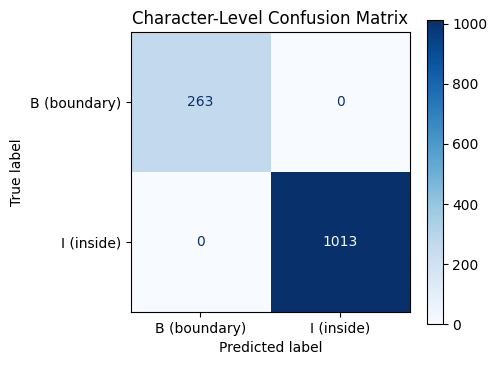

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["B", "I"])
disp = ConfusionMatrixDisplay(cm, display_labels=["B (boundary)", "I (inside)"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Character-Level Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Segmentation-Level Evaluation (Boundary F1)

In [17]:
def reconstruct_segments(word, pred_labels):
    """Convert character-level B/I predictions back to word segments."""
    segments = []
    current = ""
    for ch, label in zip(word, pred_labels):
        if label == "B":
            if current:
                segments.append(current)
            current = ch
        else:
            current += ch
    if current:
        segments.append(current)
    return segments


def get_boundaries(segments):
    boundaries = set()
    idx = 0
    for seg in segments[:-1]:
        idx += len(seg)
        boundaries.add(idx)
    return boundaries


def boundary_f1(gold, pred):
    gold_b = get_boundaries(gold)
    pred_b = get_boundaries(pred)
    
    if len(gold_b) == 0 and len(pred_b) == 0:
        return 1.0
    
    tp = len(gold_b & pred_b)
    fp = len(pred_b - gold_b)
    fn = len(gold_b - pred_b)
    
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    
    if precision + recall == 0:
        return 0
    
    return 2 * precision * recall / (precision + recall)

In [18]:
def evaluate_segmentation(sentences, trained_model, trained_vectorizer,
                           include_pos=True, include_ngrams=True):
    """Evaluate word-level segmentation using boundary F1.
    
    Extracts actual POS from annotations (not hardcoded).
    Returns (mean_f1, list of result dicts for error analysis).
    """
    results = []

    for sentence in sentences:
        for entry in get_mwt_entries(sentence):
            word = entry["form"]
            gold = entry["segments"]
            pos = "UNK"

            chars = list(word)
            feats = [char_features(chars, i, pos=pos,
                                   include_pos=include_pos,
                                   include_ngrams=include_ngrams)
                     for i in range(len(chars))]
            
            feats_vec = trained_vectorizer.transform(feats)

            # ===== STAGE 1 =====
            probs = trained_model.predict_proba(feats_vec)

            # ===== STAGE 2 =====
            corrected_probs = correct_word_predictions(
                word,
                pos,
                probs,
                trained_model,
                trained_vectorizer,
                include_pos=include_pos,
                include_ngrams=include_ngrams
            )

            # ===== FINAL LABELS =====
            pred_indices = np.argmax(corrected_probs, axis=1)
            pred_labels = trained_model.classes_[pred_indices]

            pred_segments = reconstruct_segments(word, pred_labels)
            score = boundary_f1(gold, pred_segments)

            results.append({
                "word": word,
                "gold": gold,
                "pred": pred_segments,
                "pos": pos,
                "f1": score,
            })

    mean_f1 = np.mean([r["f1"] for r in results]) if results else 0
    return mean_f1, results

In [19]:
seg_f1, seg_results = evaluate_segmentation(
    test_sentences,
    model,
    vectorizer
)

In [20]:
# =========================
# CROSS-LINGUAL EVALUATION (Spanish → Italian)
# =========================

it_seg_f1, it_seg_results = evaluate_segmentation(
    italian_test_sentences,
    model,
    vectorizer
)

print(f"\nCross-lingual Segmentation F1 (Spanish → Italian): {it_seg_f1:.4f}")
print(f"Total Italian MWT tokens evaluated: {len(it_seg_results)}")


Cross-lingual Segmentation F1 (Spanish → Italian): 0.7024
Total Italian MWT tokens evaluated: 736


In [21]:
print("\n===== SAMPLE PREDICTIONS =====\n")

for r in seg_results[:10]:
    print("WORD:", r["word"])
    print("GOLD:", r["gold"])
    print("PRED:", r["pred"])
    print("F1:", r["f1"])
    print("------")


===== SAMPLE PREDICTIONS =====

WORD: detonarla
GOLD: ['detonar', 'la']
PRED: ['detonar', 'la']
F1: 1.0
------
WORD: alzarse
GOLD: ['alzar', 'se']
PRED: ['alzar', 'se']
F1: 1.0
------
WORD: colocarlos
GOLD: ['colocar', 'los']
PRED: ['co', 'locar', 'los']
F1: 0.6666666666666666
------
WORD: hablarlo
GOLD: ['hablar', 'lo']
PRED: ['hab', 'lar', 'lo']
F1: 0.6666666666666666
------
WORD: fugarse
GOLD: ['fugar', 'se']
PRED: ['fugar', 'se']
F1: 1.0
------
WORD: atenderte
GOLD: ['atender', 'te']
PRED: ['atender', 'te']
F1: 1.0
------
WORD: encontrarla
GOLD: ['encontrar', 'la']
PRED: ['encontrar', 'la']
F1: 1.0
------
WORD: vengarse
GOLD: ['vengar', 'se']
PRED: ['vengar', 'se']
F1: 1.0
------
WORD: dotándolo
GOLD: ['dotando', 'lo']
PRED: ['dotándo', 'lo']
F1: 1.0
------
WORD: decirlo
GOLD: ['decir', 'lo']
PRED: ['decir', 'lo']
F1: 1.0
------


In [22]:
# Run segmentation evaluation on test set
seg_f1, seg_results = evaluate_segmentation(test_sentences, model, vectorizer)

print(f"Segmentation Boundary F1 (test): {seg_f1:.4f}")
print(f"Total MWT tokens evaluated: {len(seg_results)}")

# Also evaluate on dev
dev_seg_f1, _ = evaluate_segmentation(dev_sentences, model, vectorizer)
print(f"Segmentation Boundary F1 (dev):  {dev_seg_f1:.4f}")

Segmentation Boundary F1 (test): 0.9644
Total MWT tokens evaluated: 131
Segmentation Boundary F1 (dev):  0.9949


## 8. Ablation Study (Innovation Validation)

In [23]:
# Ablation: train and evaluate variants with different feature subsets
ablation_configs = {
    "Full model (POS + N-grams)":       {"include_pos": True,  "include_ngrams": True},
    "No POS":                           {"include_pos": False, "include_ngrams": True},
    "No N-grams":                       {"include_pos": True,  "include_ngrams": False},
    "Base features only":               {"include_pos": False, "include_ngrams": False},
}

ablation_results = {}

for name, kwargs in ablation_configs.items():
    # Build datasets with this feature config
    Xa_train, ya_train = build_dataset(train_sentences, **kwargs)
    Xa_test, ya_test   = build_dataset(test_sentences, **kwargs)
    
    # Vectorize
    vec_a = DictVectorizer(sparse=True)
    Xa_train_vec = vec_a.fit_transform(Xa_train)
    Xa_test_vec  = vec_a.transform(Xa_test)
    
    # Train
    clf_a = LogisticRegression(C=best_C, max_iter=500, solver="lbfgs")
    clf_a.fit(Xa_train_vec, ya_train)
    
    # Character accuracy
    ya_pred = clf_a.predict(Xa_test_vec)
    ca = accuracy_score(ya_test, ya_pred)
    
    # Segmentation F1
    sf1, _ = evaluate_segmentation(test_sentences, clf_a, vec_a, **kwargs)
    
    ablation_results[name] = {"char_acc": ca, "seg_f1": sf1, "n_features": Xa_train_vec.shape[1]}
    print(f"{name:35s}  char_acc={ca:.4f}  seg_f1={sf1:.4f}  features={Xa_train_vec.shape[1]}")

print("\nAblation complete.")

Full model (POS + N-grams)           char_acc=1.0000  seg_f1=0.9644  features=1720
No POS                               char_acc=0.9976  seg_f1=0.9924  features=1717
No N-grams                           char_acc=1.0000  seg_f1=0.9313  features=130
Base features only                   char_acc=0.9961  seg_f1=0.9975  features=127

Ablation complete.


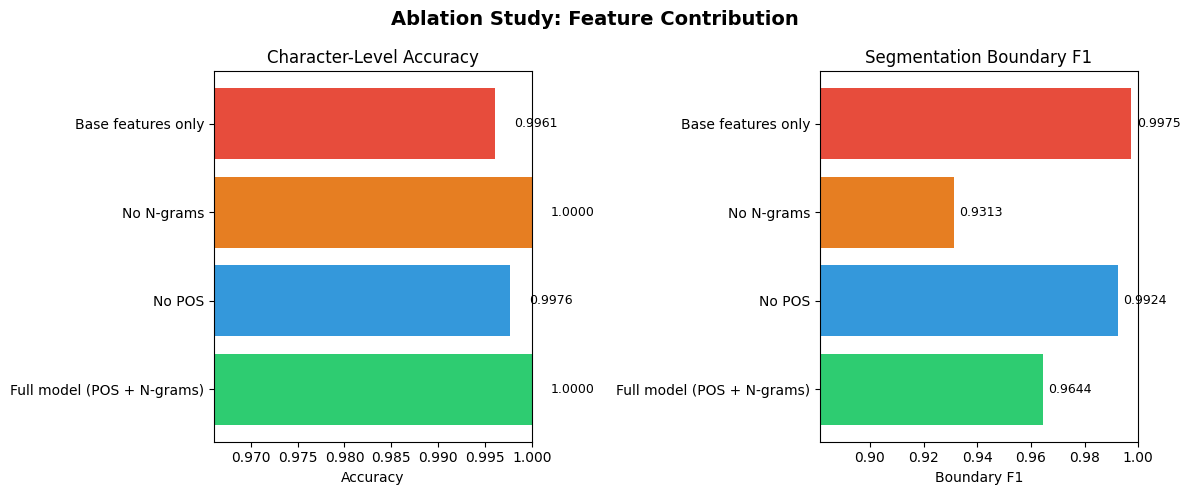

In [24]:
# Ablation comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(ablation_results.keys())
char_accs = [ablation_results[n]["char_acc"] for n in names]
seg_f1s   = [ablation_results[n]["seg_f1"] for n in names]

colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]

# Left: Character-Level Accuracy
axes[0].barh(names, char_accs, color=colors)
ca_min = min(char_accs)
axes[0].set_xlim(max(0, ca_min - 0.03), 1.0)
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Character-Level Accuracy")
for i, v in enumerate(char_accs):
    axes[0].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# Right: Segmentation Boundary F1 (dynamic axis)
axes[1].barh(names, seg_f1s, color=colors)
sf_min = min(seg_f1s)
axes[1].set_xlim(max(0, sf_min - 0.05), min(1.0, max(seg_f1s) + 0.05))
axes[1].set_xlabel("Boundary F1")
axes[1].set_title("Segmentation Boundary F1")
for i, v in enumerate(seg_f1s):
    axes[1].text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

fig.suptitle("Ablation Study: Feature Contribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Error Analysis

In [25]:
# Show correctly and incorrectly segmented examples
errors = [r for r in seg_results if r["f1"] < 1.0]
correct = [r for r in seg_results if r["f1"] == 1.0]

print(f"Correct: {len(correct)} / {len(seg_results)} ({100*len(correct)/len(seg_results):.1f}%)")
print(f"Errors:  {len(errors)} / {len(seg_results)} ({100*len(errors)/len(seg_results):.1f}%)")

if errors:
    print(f"\nMisclassified MWT tokens:")
    print(f"{'Word':<20} {'Gold':<30} {'Predicted':<30} {'POS':<8} {'F1'}")
    print("-" * 95)
    for r in errors[:20]:
        print(f"{r['word']:<20} {str(r['gold']):<30} {str(r['pred']):<30} {r['pos']:<8} {r['f1']:.2f}")

print(f"\nSample correct predictions:")
print(f"{'Word':<20} {'Gold':<30} {'Predicted':<30} {'POS'}")
print("-" * 85)
for r in correct[:10]:
    print(f"{r['word']:<20} {str(r['gold']):<30} {str(r['pred']):<30} {r['pos']}")

Correct: 117 / 131 (89.3%)
Errors:  14 / 131 (10.7%)

Misclassified MWT tokens:
Word                 Gold                           Predicted                      POS      F1
-----------------------------------------------------------------------------------------------
colocarlos           ['colocar', 'los']             ['co', 'locar', 'los']         UNK      0.67
hablarlo             ['hablar', 'lo']               ['hab', 'lar', 'lo']           UNK      0.67
poblarlo             ['poblar', 'lo']               ['pob', 'lar', 'lo']           UNK      0.67
celebrarse           ['celebrar', 'se']             ['ce', 'lebrar', 'se']         UNK      0.67
instalarse           ['instalar', 'se']             ['insta', 'lar', 'se']         UNK      0.67
alimentarse          ['alimentar', 'se']            ['ali', 'mentar', 'se']        UNK      0.67
someterse            ['someter', 'se']              ['some', 'ter', 'se']          UNK      0.67
molestarse           ['molestar', 'se']           

In [26]:
# Per-MWT-type accuracy
type_stats = {}
for r in seg_results:
    key = r["word"].lower()
    if key not in type_stats:
        type_stats[key] = {"correct": 0, "total": 0}
    type_stats[key]["total"] += 1
    if r["f1"] == 1.0:
        type_stats[key]["correct"] += 1

# Show accuracy per MWT type (sorted by frequency)
print(f"{'MWT Form':<20} {'Correct':<10} {'Total':<10} {'Accuracy'}")
print("-" * 55)
for form, stats in sorted(type_stats.items(), key=lambda x: -x[1]["total"])[:15]:
    acc = stats["correct"] / stats["total"]
    print(f"{form:<20} {stats['correct']:<10} {stats['total']:<10} {acc:.2%}")

MWT Form             Correct    Total      Accuracy
-------------------------------------------------------
convirtiéndose       8          8          100.00%
dedicarse            7          7          100.00%
mantenerse           5          5          100.00%
vengarse             3          3          100.00%
centrarse            3          3          100.00%
alzarse              2          2          100.00%
fugarse              2          2          100.00%
decirlo              2          2          100.00%
celebrarse           0          2          0.00%
tocándose            2          2          100.00%
darles               2          2          100.00%
educarse             2          2          100.00%
conocerse            0          2          0.00%
detonarla            1          1          100.00%
colocarlos           0          1          0.00%


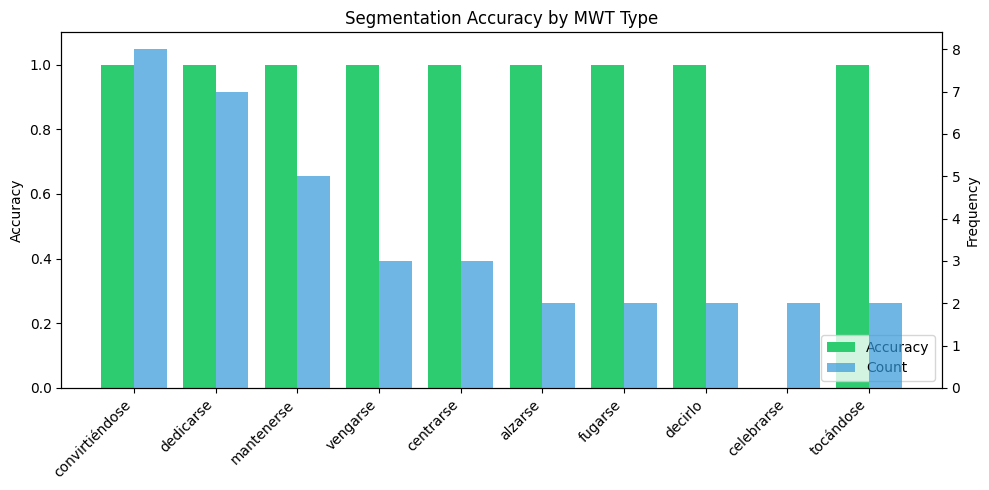

In [27]:
# Per-MWT-type accuracy visualization
forms = []
accs = []
counts = []
for form, stats in sorted(type_stats.items(), key=lambda x: -x[1]["total"])[:10]:
    forms.append(form)
    accs.append(stats["correct"] / stats["total"])
    counts.append(stats["total"])

fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(forms))
width = 0.4

bars1 = ax1.bar(x - width/2, accs, width, label="Accuracy", color="#2ecc71")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, counts, width, label="Count", color="#3498db", alpha=0.7)
ax2.set_ylabel("Frequency")

ax1.set_xticks(x)
ax1.set_xticklabels(forms, rotation=45, ha="right")
ax1.set_title("Segmentation Accuracy by MWT Type")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

plt.tight_layout()
plt.show()

## 10. Summary

In [28]:
# Final summary table
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"{'Metric':<40} {'Score':>10}")
print("-" * 65)

print(f"{'Character-Level Accuracy (test)':<40} {char_acc:>10.4f}")
print(f"{'Segmentation Boundary F1 (test)':<40} {seg_f1:>10.4f}")
print(f"{'Segmentation Boundary F1 (dev)':<40} {dev_seg_f1:>10.4f}")

# NEW LINE 👇 (your innovation result)
print(f"{'Segmentation F1 (Spanish → Italian)':<40} {it_seg_f1:>10.4f}")

print(f"{'MWT tokens correctly segmented':<40} {f'{len(correct)}/{len(seg_results)}':>10}")

print("-" * 65)

print(f"\n{'ABLATION STUDY':}")
print("-" * 65)
print(f"{'Configuration':<35} {'Char Acc':>10} {'Seg F1':>10} {'Features':>8}")
print("-" * 65)

for name, res in ablation_results.items():
    print(f"{name:<35} {res['char_acc']:>10.4f} {res['seg_f1']:>10.4f} {res['n_features']:>8}")

print("=" * 65)

FINAL RESULTS SUMMARY
Metric                                        Score
-----------------------------------------------------------------
Character-Level Accuracy (test)              1.0000
Segmentation Boundary F1 (test)              0.9644
Segmentation Boundary F1 (dev)               0.9949
Segmentation F1 (Spanish → Italian)          0.7024
MWT tokens correctly segmented              117/131
-----------------------------------------------------------------

ABLATION STUDY
-----------------------------------------------------------------
Configuration                         Char Acc     Seg F1 Features
-----------------------------------------------------------------
Full model (POS + N-grams)              1.0000     0.9644     1720
No POS                                  0.9976     0.9924     1717
No N-grams                              1.0000     0.9313      130
Base features only                      0.9961     0.9975      127
